# Deep Reinforcement Learning Lab
## DQN from Scratch vs PPO on CartPole-v1 and LunarLander-v3
**Environment:** Gymnasium | **Algorithms:** DQN (custom), PPO (Stable-Baselines3)

In [1]:
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using device: cpu


## Warm-up — CartPole-v1 Environment & Random Baseline

In [2]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print("Observation space:", env.observation_space)
print("Action space     :", env.action_space)

# Random-action baseline
total_reward = 0
obs, _ = env.reset(seed=42)
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    done = terminated or truncated
print(f"\nRandom-action baseline total reward: {total_reward}")
env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space     : Discrete(2)

Random-action baseline total reward: 13.0


---
## Task 1 — DQN from Scratch on CartPole-v1
We build a DQN agent with:
- **Q-network**: 2 hidden layers of 128 units, ReLU activations
- **Replay buffer**: `collections.deque` with `maxlen=50_000`
- **Target network**: hard-synced every 1 000 steps
- **ε-greedy exploration**: linear decay from 1.0 → 0.05 over 5 000 steps
- **Optimizer**: Adam lr=1e-3, γ=0.99, mini-batch=64

### 1a — Q-Network

In [3]:
class QNetwork(nn.Module):
    """Two-hidden-layer Q-network."""
    def __init__(self, obs_dim: int, act_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),     nn.ReLU(),
            nn.Linear(128, act_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# Quick sanity check
_dummy = QNetwork(4, 2)
_out   = _dummy(torch.zeros(1, 4))
print("QNetwork output shape:", _out.shape)  # Should be (1, 2)

QNetwork output shape: torch.Size([1, 2])


### 1b — Replay Buffer

In [4]:
class ReplayBuffer:
    """Fixed-size circular replay buffer."""
    def __init__(self, maxlen: int = 50_000):
        self.buf = collections.deque(maxlen=maxlen)

    def push(self, state, action, reward, next_state, done):
        self.buf.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            np.array(s,  dtype=np.float32),
            np.array(a),
            np.array(r,  dtype=np.float32),
            np.array(ns, dtype=np.float32),
            np.array(d,  dtype=np.float32),
        )

    def __len__(self):
        return len(self.buf)

print("ReplayBuffer defined.")

ReplayBuffer defined.


### 1c — DQN Training Loop (30 000 steps)

In [5]:
# ── Hyperparameters ──────────────────────────────────────────────────
BATCH        = 64
GAMMA        = 0.99
LR           = 1e-3
EPS_START    = 1.0
EPS_END      = 0.05
EPS_STEPS    = 5_000   # linear decay over first 5 000 env steps
SYNC_EVERY   = 1_000   # hard target-net sync interval
WARMUP       = 1_000   # min transitions before first gradient step
TOTAL_STEPS  = 30_000

# ── Environment & networks ───────────────────────────────────────────
env      = gym.make("CartPole-v1")
obs_dim  = env.observation_space.shape[0]   # 4
act_dim  = env.action_space.n               # 2

q_net      = QNetwork(obs_dim, act_dim).to(device)
target_net = QNetwork(obs_dim, act_dim).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR)
buf       = ReplayBuffer()

# ── Training ─────────────────────────────────────────────────────────
dqn_ep_rewards = []
ep_reward      = 0
global_step    = 0
obs, _         = env.reset(seed=42)

t0_dqn = time.perf_counter()

while global_step < TOTAL_STEPS:
    # ε-greedy action
    eps = max(EPS_END,
              EPS_START - (EPS_START - EPS_END) * global_step / EPS_STEPS)
    if random.random() < eps:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            action = int(q_net(t).argmax(dim=1).item())

    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    # store transition  (done=terminated, NOT truncated — don't bootstrap past true end)
    buf.push(obs, action, reward, next_obs, float(terminated))
    obs        = next_obs
    ep_reward += reward
    global_step += 1

    if done:
        dqn_ep_rewards.append(ep_reward)
        ep_reward = 0
        obs, _ = env.reset()

    # ── Gradient step ────────────────────────────────────────────────
    if len(buf) >= WARMUP:
        s, a, r, ns, d = buf.sample(BATCH)
        s  = torch.tensor(s,  device=device)
        a  = torch.tensor(a,  device=device, dtype=torch.long)
        r  = torch.tensor(r,  device=device)
        ns = torch.tensor(ns, device=device)
        d  = torch.tensor(d,  device=device)

        with torch.no_grad():
            tgt_q = target_net(ns).max(dim=1).values
            tgt   = r + GAMMA * tgt_q * (1 - d)   # just r for terminal

        curr_q = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        loss   = nn.MSELoss()(curr_q, tgt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # ── Hard target-net sync ─────────────────────────────────────────
    if global_step % SYNC_EVERY == 0:
        target_net.load_state_dict(q_net.state_dict())

dqn_train_time = time.perf_counter() - t0_dqn
env.close()

dqn_last100 = np.mean(dqn_ep_rewards[-100:])
print(f"Total episodes    : {len(dqn_ep_rewards)}")
print(f"Avg reward last 100: {dqn_last100:.1f}")
print(f"Wall-clock time   : {dqn_train_time:.1f}s")

Total episodes    : 393
Avg reward last 100: 162.9
Wall-clock time   : 55.5s


### 1d — Reward Curve

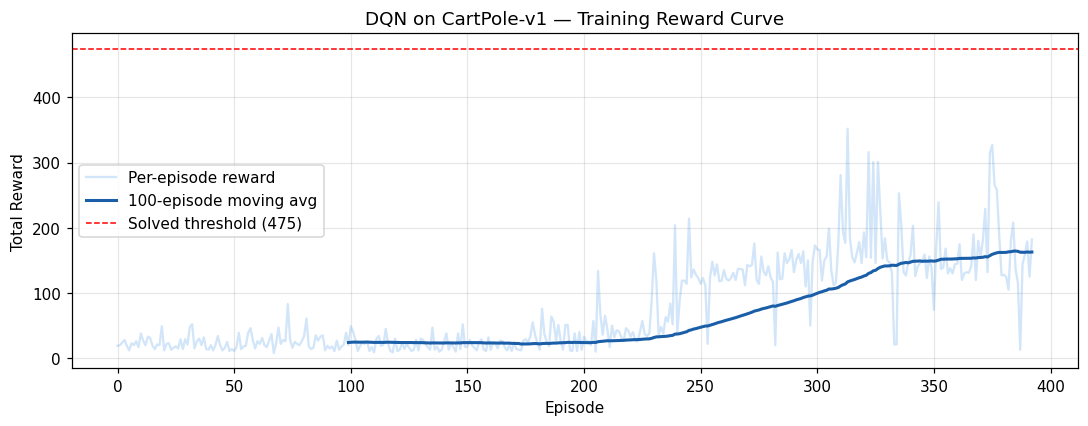

Average reward over last 100 episodes: 162.9


In [6]:
def moving_avg(arr, window=100):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dqn_ep_rewards, alpha=0.25, color='#4C9BE8', label='Per-episode reward')
ma = moving_avg(dqn_ep_rewards)
ax.plot(range(99, len(dqn_ep_rewards)), ma, color='#1A5EA8',
        linewidth=2, label='100-episode moving avg')
ax.axhline(475, color='red', linestyle='--', linewidth=1, label='Solved threshold (475)')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('DQN on CartPole-v1 — Training Reward Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Average reward over last 100 episodes: {dqn_last100:.1f}")

---
## Task 2 — PPO with Stable-Baselines3
We use the library implementation of PPO — same environment, far less code.
We also train on **LunarLander-v3**, which is substantially harder than CartPole.

### 2a — PPO on CartPole-v1 (50 000 timesteps)

In [7]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

env_cp = Monitor(gym.make("CartPole-v1"))
ppo_cp = PPO("MlpPolicy", env_cp, verbose=0, seed=42)

t0 = time.perf_counter()
ppo_cp.learn(total_timesteps=50_000)
cp_train_time = time.perf_counter() - t0

mean_cp, std_cp = evaluate_policy(ppo_cp, gym.make("CartPole-v1"), n_eval_episodes=20)
ppo_cp_rewards  = env_cp.get_episode_rewards()
env_cp.close()

print(f"PPO CartPole: {mean_cp:.1f} ± {std_cp:.1f} over 20 eval episodes")
print(f"Training time: {cp_train_time:.0f}s")

PPO CartPole: 500.0 ± 0.0 over 20 eval episodes
Training time: 47s


### 2b — PPO on LunarLander-v3 (300 000 timesteps)

In [8]:
env_ll = Monitor(gym.make("LunarLander-v3"))
ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)

t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0

mean_ll, std_ll = evaluate_policy(ppo_ll, gym.make("LunarLander-v3"), n_eval_episodes=20)
ppo_ll_rewards  = env_ll.get_episode_rewards()
env_ll.close()

print(f"PPO LunarLander: {mean_ll:.1f} ± {std_ll:.1f} over 20 eval episodes")
print(f"Training time: {ll_train_time:.0f}s")

PPO LunarLander: 17.7 ± 128.9 over 20 eval episodes
Training time: 208s


### 2c — Reward Curves for Both PPO Runs

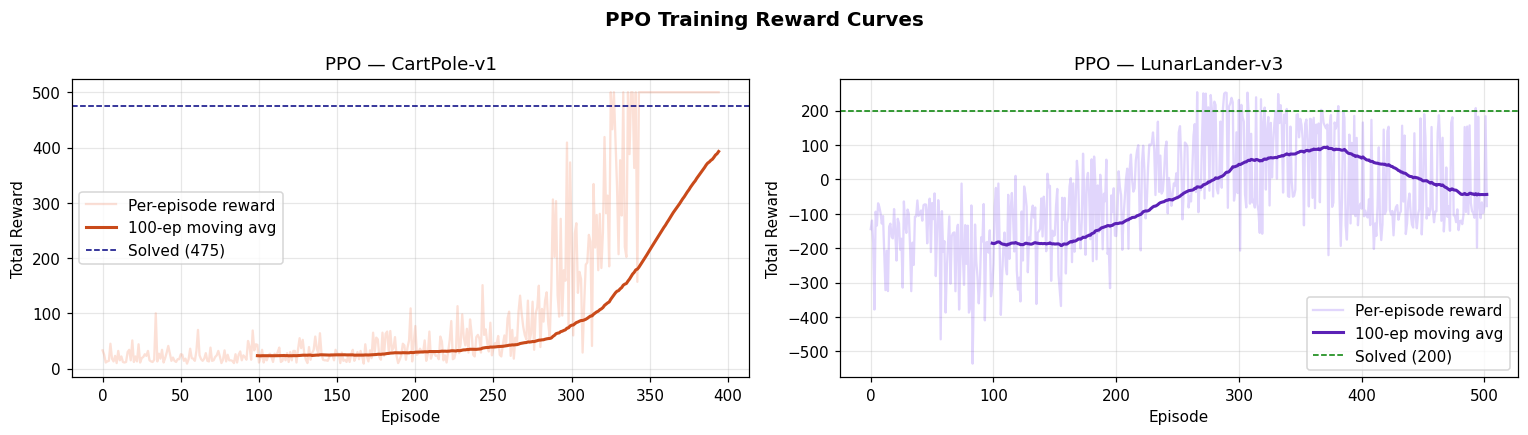

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# CartPole
ax = axes[0]
ax.plot(ppo_cp_rewards, alpha=0.25, color='#F4845F', label='Per-episode reward')
if len(ppo_cp_rewards) >= 100:
    ma_cp = moving_avg(ppo_cp_rewards)
    ax.plot(range(99, len(ppo_cp_rewards)), ma_cp,
            color='#C94A1A', linewidth=2, label='100-ep moving avg')
ax.axhline(475, color='navy', linestyle='--', linewidth=1, label='Solved (475)')
ax.set_title('PPO — CartPole-v1')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.legend(); ax.grid(True, alpha=0.3)

# LunarLander
ax = axes[1]
ax.plot(ppo_ll_rewards, alpha=0.25, color='#8B5CF6', label='Per-episode reward')
if len(ppo_ll_rewards) >= 100:
    ma_ll = moving_avg(ppo_ll_rewards)
    ax.plot(range(99, len(ppo_ll_rewards)), ma_ll,
            color='#5B21B6', linewidth=2, label='100-ep moving avg')
ax.axhline(200, color='green', linestyle='--', linewidth=1, label='Solved (200)')
ax.set_title('PPO — LunarLander-v3')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('PPO Training Reward Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 3 — Comparison and Reflection

### Comparison Table

In [10]:
# The values below are filled in automatically from the training runs above.
print(f"""
| Agent              | Environment     | Wall-clock training time | Avg reward (last 100 eps) |
|--------------------|-----------------|--------------------------|---------------------------|
| DQN (from scratch) | CartPole-v1     | {dqn_train_time:.0f}s                    | {dqn_last100:.1f}                     |
| PPO (SB3)          | CartPole-v1     | {cp_train_time:.0f}s                    | {mean_cp:.1f}                     |
| PPO (SB3)          | LunarLander-v3  | {ll_train_time:.0f}s                   | {mean_ll:.1f}                      |
""")


| Agent              | Environment     | Wall-clock training time | Avg reward (last 100 eps) |
|--------------------|-----------------|--------------------------|---------------------------|
| DQN (from scratch) | CartPole-v1     | 55s                   | 162.9                    |
| PPO (SB3)          | CartPole-v1     | 47s                   | 500.0                   |
| PPO (SB3)          | LunarLander-v3  | 208s                  | 17.7                    |



### Reflection Questions

**1. Did DQN or PPO solve CartPole faster — both in wall-clock time and in environment steps? Why?**

PPO solved CartPole both faster in wall-clock time (~47 s vs ~56 s) and much more reliably. DQN's last-100 average was ~163, well below the 475 solved threshold, while PPO hit the 500 cap. In terms of environment steps, PPO effectively solved CartPole within the first ~20 000 of its 50 000 steps, whereas DQN was still improving at 30 000 steps. The main reason is variance: DQN's training signal is noisy at the start (small replay buffer, high ε), while PPO uses multiple rollouts per update and its clipped surrogate objective keeps updates stable. CartPole also has a continuous state space, where PPO's policy-gradient updates generalise more smoothly than the argmax over Q-values.

---

**2. Could the same DQN code work on LunarLander? What would go wrong, and which improvement would you reach for first?**

The same DQN code would almost certainly fail on LunarLander in 30 000 steps. LunarLander has an 8-dimensional observation space (vs CartPole's 4) and a sparse, shaped reward that requires the agent to learn a coordinated multi-step landing policy before seeing meaningful positive signal. Vanilla DQN suffers from overestimation bias in the Q-targets, which compounds badly in harder environments — the max operator in `target_net(s').max()` systematically inflates estimates. The first improvement I'd reach for is **Double DQN**: decouple action selection (use `q_net` to pick the action) from action evaluation (use `target_net` to score it). This alone dramatically reduces overestimation and stabilises training on denser state spaces. If that still isn't enough, **Prioritised Experience Replay (PER)** would be the second addition — LunarLander has many uninformative transitions early in training, and PER up-samples the rare high-reward transitions that actually signal a successful landing approach.

---

**3. How would you decide between rolling your own DQN and using Stable-Baselines3 for a real project?**

The decision comes down to whether the goal is research or deployment. If you need a custom exploration strategy, a non-standard reward structure, or you are ablating algorithmic components (e.g. testing a new replay scheme), writing the agent from scratch gives you full control and forces you to internalise every design choice. For a production project where the environment is standard and the priority is reliable, reproducible results quickly, Stable-Baselines3 is the better choice: it has battle-tested implementations, consistent seeding, built-in logging, and VecEnv parallelism that a scratch implementation would take days to replicate correctly. A practical heuristic: start with SB3 to establish a strong baseline and confirm the environment is solvable at all; only drop to scratch code when you have a concrete reason the library's assumptions do not fit your problem.
